<a href="https://colab.research.google.com/github/Havi-boop/havi-/blob/main/Modelo_procesal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%bash
pip install automata-lib
pip install pandas
pip install graphviz
pip install colormath
pip install jupyterlab
pip install visual-automata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for colormath: filename=colormath-3.0.0-py3-none-any.whl size=39405 sha256=23bd42cae1646a4da4689006351a39e084739eac70a186b238496c4a4a9de0ae
  Stored in directory: /root/.cache/pip/wheels/f5/ce/f7/7039d7b57e1a27fc2f6bb2b2abed1be362eefece03caf2fb9a
Successfully built colormath
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.6.3 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.6.3 which is incompatible.


In [2]:
%%bash
pip install visual-automata

In [3]:
from automata.fa.dfa import DFA
from visual_automata.fa.dfa import VisualDFA

dfa = VisualDFA(
    states={"q0", "q1", "q2"},
    input_symbols={"0", "1"},
    transitions={
        "q0": {"a": "q0", "b": "q1"},
       "q1" :{"a":"q0","b":"q2"},
        "q2" :{"a":"q0","b":"q3"},
        "q3" :{"a":"q3","b":"q3"},
    },
    initial_state="q0",
    final_states={"q0", "q1" ,"q2"},
)
dfa.show_diagram("ab")

MissingSymbolError: state q0 is missing transitions for symbol "1"

Autor: Havi Calderon Mendoza

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Cargar dataset MNIST
print("Cargando dataset MNIST...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Definir modelo secuencial
print("Construyendo el modelo...")
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# Compilar modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar modelo
print("Entrenando modelo...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluar modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nPrecisión final en datos de prueba: {test_acc:.4f}")

# Guardar modelo
model.save("modelo_mnist.h5")
print("Modelo guardado como modelo_mnist.h5")

# Graficar precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Pruebas con imágenes externas (opcional)
carpeta_pruebas = "pruebas"
if os.path.exists(carpeta_pruebas):
    print("\nIniciando pruebas con imágenes externas...")
    for nombre_img in os.listdir(carpeta_pruebas):
        ruta = os.path.join(carpeta_pruebas, nombre_img)
        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Error al cargar imagen: {ruta}")
            continue
        img = cv2.resize(img, (28, 28))
        img = 255 - img  # Invertir blanco y negro si necesario
        img = img / 255.0
        img = img.reshape(1, 28, 28)

        pred = model.predict(img)
        resultado = np.argmax(pred)
        print(f"Imagen {nombre_img} -> Predicción: {resultado}")
else:
    print("\nNo se encontró carpeta 'pruebas'. Crea una carpeta con imágenes 28x28 de dígitos manuscritos para probar el modelo.")


Cargando dataset MNIST...


Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: 500 -- Internal Server Error

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargar dataset MNIST
print("Cargando dataset MNIST...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Definir modelo secuencial
print("Construyendo el modelo...")
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# Compilar modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar modelo
print("Entrenando modelo...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluar modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nPrecisión final en datos de prueba: {test_acc:.4f}")

# Guardar modelo
model.save("modelo_mnist.h5")
print("Modelo guardado como modelo_mnist.h5")

# Graficar precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Mostrar imágenes del conjunto de prueba con predicciones
print("\nMostrando predicciones con imágenes del conjunto de prueba MNIST...")

num_ejemplos = 10  # Número de imágenes a mostrar
indices = np.random.choice(len(x_test), num_ejemplos, replace=False)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    img = x_test[idx]
    label_real = y_test[idx]
    img_entrada = img.reshape(1, 28, 28)

    pred = model.predict(img_entrada, verbose=0)
    pred_clase = np.argmax(pred)
    confianza = np.max(pred)

    plt.subplot(1, num_ejemplos, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred_clase}\nReal: {label_real}\nConf: {confianza:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Cargando dataset MNIST...


Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: 500 -- Internal Server Error

Cargando dataset MNIST...
Construyendo el modelo...
Entrenando modelo...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8530 - loss: 0.5025 - val_accuracy: 0.9582 - val_loss: 0.1405
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9542 - loss: 0.1548 - val_accuracy: 0.9685 - val_loss: 0.1080
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9664 - loss: 0.1105 - val_accuracy: 0.9726 - val_loss: 0.0896
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9740 - loss: 0.0859 - val_accuracy: 0.9769 - val_loss: 0.0756
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9768 - loss: 0.0748 - val_accuracy: 0.9788 - val_loss: 0.0751
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9751 - loss: 0.0886



Precisión final en datos de prueba: 0.9788
Modelo guardado como modelo_mnist.h5


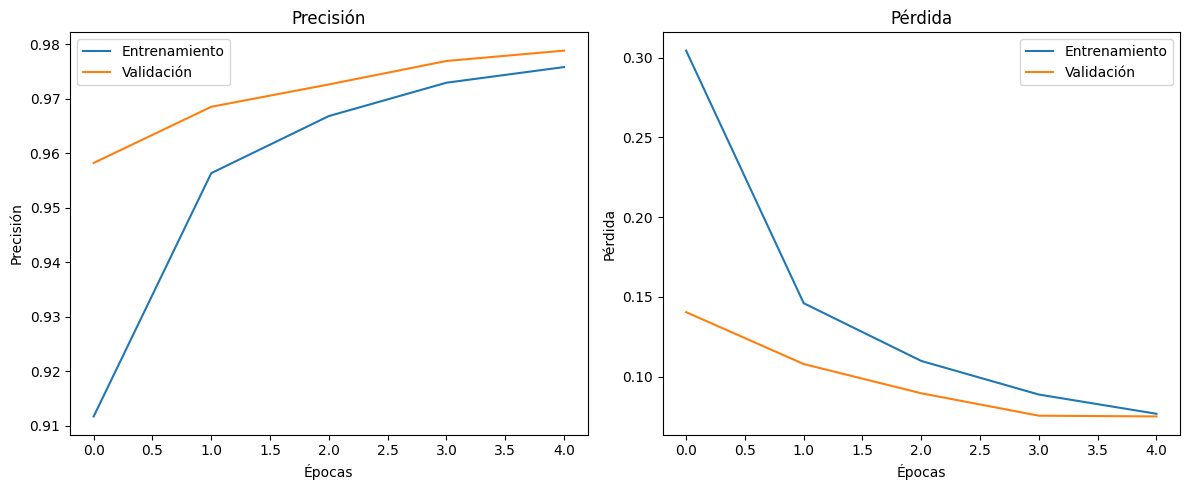


Mostrando predicciones con imágenes del conjunto de prueba MNIST...


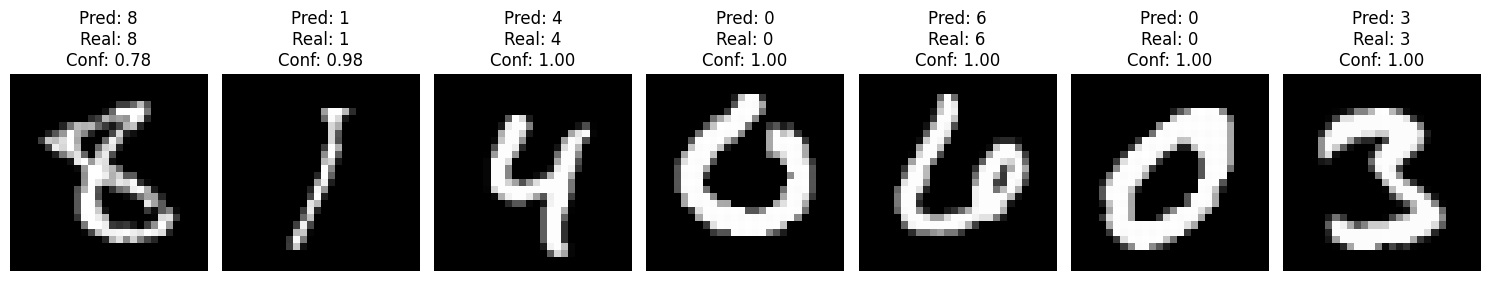

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargar dataset MNIST
print("Cargando dataset MNIST...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Definir modelo secuencial
print("Construyendo el modelo...")
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# Compilar modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar modelo
print("Entrenando modelo...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluar modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nPrecisión final en datos de prueba: {test_acc:.4f}")

# Guardar modelo
model.save("modelo_mnist.h5")
print("Modelo guardado como modelo_mnist.h5")

# Graficar precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Mostrar imágenes del conjunto de prueba con predicciones
print("\nMostrando predicciones con imágenes del conjunto de prueba MNIST...")

num_ejemplos = 7  # Número de imágenes a mostrar
indices = np.random.choice(len(x_test), num_ejemplos, replace=False)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    img = x_test[idx]
    label_real = y_test[idx]
    img_entrada = img.reshape(1, 28, 28)

    pred = model.predict(img_entrada, verbose=0)
    pred_clase = np.argmax(pred)
    confianza = np.max(pred)

    plt.subplot(1, num_ejemplos, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred_clase}\nReal: {label_real}\nConf: {confianza:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()
